<a href="https://colab.research.google.com/github/kaushal4445/GEN_AI-TRAINING-CGC-UNIVERSITY/blob/main/LEARNING_PYTHON/Gen_AI_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("kaushal")

kaushal


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression

with th e hep of inear regression  we av use a function called a sigmoid function

sigmoid fuction will convert linear line into sigmoid value

sigmoid value always 0 or 1

sigmoid value exact 0 or 1

0.1 to 0.5  = 0

0.5 > 1


this fuction is used to convert linear line to curve line

beacuase linear line gives in point value

curve line gives 0 or 1



The sigmoid function is:

$$ \boxed{\sigma(x)=\frac{1}{1+e^{-x}}} $$

where:

\(x\) = input
\(e \approx 2.71828\)
Output is always between 0 and 1

For example, when \(x=0\):

$$ \sigma(0)=\frac{1}{1+e^0}=\frac12=0.5 $$

It is commonly used as an activation function in neural networks and for

converting logits to probabilities in logistic regression.

# **Binary classificatiion using linear and logistic regression**

X_train , y_pred ;- Simple model score

X_test , y_test :- X_test value internally test /  train then score

y_test, y_pred :- compare behave score generates (classification -----  accuracy)

In [ ]:
x = np.random.random(30)
x

array([0.61379752, 0.44968516, 0.41101036, 0.24959509, 0.81466125,
       0.1118134 , 0.14141559, 0.20684495, 0.04037317, 0.75268194,
       0.27146352, 0.35605559, 0.26595539, 0.70956873, 0.97753155,
       0.3805644 , 0.71383191, 0.22856912, 0.28258804, 0.90309508,
       0.18157482, 0.83516896, 0.81732548, 0.66002441, 0.67197121,
       0.89233217, 0.59203862, 0.06171008, 0.11229154, 0.94165597])

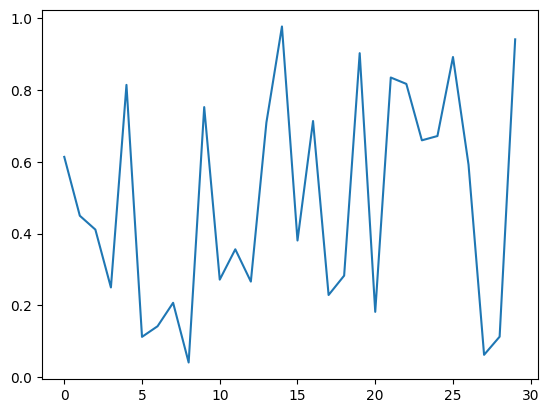

In [ ]:
plt.plot(x)
plt.show()

Create sigmoid function

In [ ]:
def sigmoid_fun(x):
  return 1/(1+2.71**(-x))

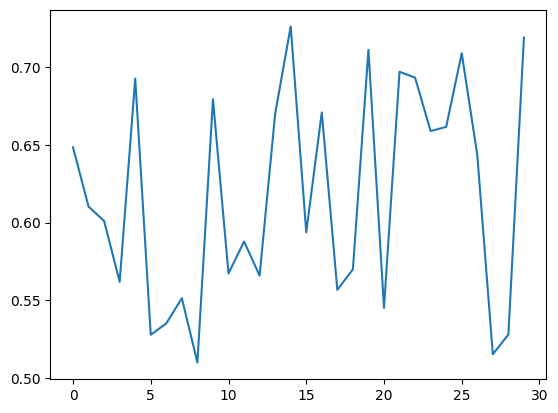

In [ ]:
sigmoid_x = sigmoid_fun(x)
plt.plot(sigmoid_x)
plt.show()


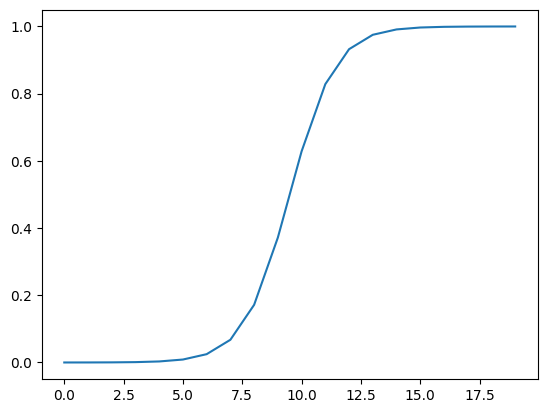

In [ ]:
new_x = np.linspace(-10, 10, 20)
sigmoid_x_new = sigmoid_fun(new_x)
plt.plot(sigmoid_x_new)
plt.show()

In [ ]:
df = pd.read_csv("myinsurance.csv")

In [ ]:
df

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,Male,25000,0,Single,0,0,1,No
1,2,25,Female,30000,0,Single,0,0,1,No
2,3,28,Male,35000,1,Single,0,0,1,No
3,4,30,Female,40000,1,Single,0,1,2,Yes
4,5,32,Male,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...,...
95,96,46,Female,70000,1,Married,1,2,4,Yes
96,97,51,Male,83000,1,Married,1,3,4,Yes
97,98,56,Female,94000,1,Married,1,3,4,Yes
98,99,24,Male,31000,0,Single,0,0,1,No


Start EDA

In [ ]:
df.tail()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
95,96,46,Female,70000,1,Married,1,2,4,Yes
96,97,51,Male,83000,1,Married,1,3,4,Yes
97,98,56,Female,94000,1,Married,1,3,4,Yes
98,99,24,Male,31000,0,Single,0,0,1,No
99,100,30,Female,40000,1,Single,0,1,2,Yes


In [ ]:
df.shape

(100, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         100 non-null    int64 
 1   Age                 100 non-null    int64 
 2   Gender              100 non-null    object
 3   Annual_Income       100 non-null    int64 
 4   Employment_Status   100 non-null    int64 
 5   Marital_Status      100 non-null    object
 6   Married             100 non-null    int64 
 7   Previous_Insurance  100 non-null    int64 
 8   Family_Size         100 non-null    int64 
 9   Buy_Insurance       100 non-null    object
dtypes: int64(7), object(3)
memory usage: 7.9+ KB


corr() can take only numeric data

In [ ]:
df.corr(numeric_only=True)

,Customer_ID,Age,Annual_Income,Employment_Status,Married,Previous_Insurance,Family_Size
Customer_ID,1.000000,0.158170,0.180054,0.049803,0.133401,0.156457,0.150810
Age,0.158170,1.000000,0.998332,0.650960,0.834590,0.960055,0.956927
Annual_Income,0.180054,0.998332,1.000000,0.650526,0.839337,0.961360,0.957596
Employment_Status,0.049803,0.650960,0.650526,1.000000,0.557578,0.610820,0.689424
Married,0.133401,0.834590,0.839337,0.557578,1.000000,0.820608,0.848247
Previous_Insurance,0.156457,0.960055,0.961360,0.610820,0.820608,1.000000,0.933681
Family_Size,0.150810,0.956927,0.957596,0.689424,0.848247,0.933681,1.000000


In [ ]:
text_data = list[df.select_dtypes(object).columns]
text_data

list[Index(['Gender', 'Marital_Status', 'Buy_Insurance'], dtype='object')]

In [ ]:
df.sample()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
90,91,23,Male,29000,0,Single,0,0,1,No


In [ ]:
for i in text_data:
  print(f"Analysis of {i}")
  display(df[i].value_counts())

Analysis of *list[Index(['Gender', 'Marital_Status', 'Buy_Insurance'], dtype='object')]


,,,,,,,,,,count
Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance,
1,22,Male,25000,0,Single,0,0,1,No,1
2,25,Female,30000,0,Single,0,0,1,No,1
3,28,Male,35000,1,Single,0,0,1,No,1
4,30,Female,40000,1,Single,0,1,2,Yes,1
5,32,Male,45000,1,Single,0,1,2,Yes,1
...,...,...,...,...,...,...,...,...,...,...
96,46,Female,70000,1,Married,1,2,4,Yes,1
97,51,Male,83000,1,Married,1,3,4,Yes,1
98,56,Female,94000,1,Married,1,3,4,Yes,1


In [ ]:
df["Gender"] = df["Gender"].replace({"Male":1, "Female":0})
df

/tmp/ipykernel_2256/594654955.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace({"Male":1, "Female":0})


,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,1,25000,0,Single,0,0,1,No
1,2,25,0,30000,0,Single,0,0,1,No
2,3,28,1,35000,1,Single,0,0,1,No
3,4,30,0,40000,1,Single,0,1,2,Yes
4,5,32,1,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...,...
95,96,46,0,70000,1,Married,1,2,4,Yes
96,97,51,1,83000,1,Married,1,3,4,Yes
97,98,56,0,94000,1,Married,1,3,4,Yes
98,99,24,1,31000,0,Single,0,0,1,No


In [ ]:
df["Marital_Status"] = df["Marital_Status"].replace({"Married":1, "Single":0})
df

/tmp/ipykernel_2256/1547879631.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Marital_Status"] = df["Marital_Status"].replace({"Married":1, "Single":0})


,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,1,25000,0,0,0,0,1,No
1,2,25,0,30000,0,0,0,0,1,No
2,3,28,1,35000,1,0,0,0,1,No
3,4,30,0,40000,1,0,0,1,2,Yes
4,5,32,1,45000,1,0,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...,...
95,96,46,0,70000,1,1,1,2,4,Yes
96,97,51,1,83000,1,1,1,3,4,Yes
97,98,56,0,94000,1,1,1,3,4,Yes
98,99,24,1,31000,0,0,0,0,1,No


In [ ]:
df["Buy_Insurance"] = df["Buy_Insurance"].replace({"Yes":1, "No":0})
df

/tmp/ipykernel_2256/712938414.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Buy_Insurance"] = df["Buy_Insurance"].replace({"Yes":1, "No":0})


,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,1,25000,0,0,0,0,1,0
1,2,25,0,30000,0,0,0,0,1,0
2,3,28,1,35000,1,0,0,0,1,0
3,4,30,0,40000,1,0,0,1,2,1
4,5,32,1,45000,1,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...
95,96,46,0,70000,1,1,1,2,4,1
96,97,51,1,83000,1,1,1,3,4,1
97,98,56,0,94000,1,1,1,3,4,1
98,99,24,1,31000,0,0,0,0,1,0


In [ ]:
df.corr().round(2)

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
Customer_ID,1.00,0.16,-0.02,0.18,0.05,0.13,0.13,0.16,0.15,0.09
Age,0.16,1.00,-0.02,1.00,0.65,0.83,0.83,0.96,0.96,0.73
Gender,-0.02,-0.02,1.00,-0.02,0.02,0.02,0.02,-0.02,-0.01,-0.02
Annual_Income,0.18,1.00,-0.02,1.00,0.65,0.84,0.84,0.96,0.96,0.73
Employment_Status,0.05,0.65,0.02,0.65,1.00,0.56,0.56,0.61,0.69,0.82
Marital_Status,0.13,0.83,0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Married,0.13,0.83,0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Previous_Insurance,0.16,0.96,-0.02,0.96,0.61,0.82,0.82,1.00,0.93,0.75
Family_Size,0.15,0.96,-0.01,0.96,0.69,0.85,0.85,0.93,1.00,0.77
Buy_Insurance,0.09,0.73,-0.02,0.73,0.82,0.68,0.68,0.75,0.77,1.00


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns = ["Buy_Insurance", "Customer_ID"])
y = df["Buy_Insurance"]

In [ ]:
X.shape

(100, 8)

In [ ]:
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(80, 8)
(20, 8)
(80,)
(20,)


In [ ]:
model  =LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 0.71072184,  1.12604542,  0.9805892 ,  0.9277091 ,  0.85674055,
        0.97519146,  0.79790808,  0.88099038, -0.16123934,  0.01860019,
       -0.0217355 ,  1.01000544, -0.02670258, -0.00486368,  0.01102285,
        0.77736299,  0.78936777,  1.09662918,  0.79585977,  1.01692078])

In [ ]:
y_test

,Buy_Insurance
83,0
53,1
70,1
45,1
44,1
39,1
22,1
80,1
10,0
0,0


In [ ]:
sigmoid_fun(y_pred)

array([0.67008138, 0.75447242, 0.72663116, 0.71603505, 0.70143202,
       0.72556093, 0.68900536, 0.70647026, 0.45989948, 0.50463572,
       0.49458292, 0.73241765, 0.49334512, 0.49878779, 0.50274728,
       0.68459955, 0.68717802, 0.74899942, 0.68856763, 0.73376663])

In [ ]:
final_y_ped = [round(i) for  i in sigmoid_fun(y_pred)]
final_y_ped

[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]

In [ ]:
score  = model.score(X_test,  y_test)
score
#

0.8295024967963622

In [ ]:
model_logistic = LogisticRegression()
model_logistic

LogisticRegression()

In [ ]:
model_logistic.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 0.71072184,  1.12604542,  0.9805892 ,  0.9277091 ,  0.85674055,
        0.97519146,  0.79790808,  0.88099038, -0.16123934,  0.01860019,
       -0.0217355 ,  1.01000544, -0.02670258, -0.00486368,  0.01102285,
        0.77736299,  0.78936777,  1.09662918,  0.79585977,  1.01692078])

In [ ]:
sigmoid_fun(y_pred)

array([0.67008138, 0.75447242, 0.72663116, 0.71603505, 0.70143202,
       0.72556093, 0.68900536, 0.70647026, 0.45989948, 0.50463572,
       0.49458292, 0.73241765, 0.49334512, 0.49878779, 0.50274728,
       0.68459955, 0.68717802, 0.74899942, 0.68856763, 0.73376663])

In [ ]:
final_y_ped = [round(i) for  i in sigmoid_fun(y_pred)]
final_y_ped

[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]

In [ ]:
score  = model_logistic.score(X_test,  y_test)
score

0.95

In [ ]:
Age = float(input("Enter Age: "))
Gender = float(input("Enter Gender: "))
Annual_Income = float(input("Enter Annual Income: "))
Employment_Status = float(input("Enter Employment Status: "))
Marital_Status = float(input("Enter Marital Status: "))
Married = float(input("Enter Married (1 = Yes, 0 = No): "))
Previous_Insurance = float(input("Enter Previous Insurance (1 = Yes, 0 = No): "))
Family_Size = float(input("Enter Family Size: "))


user_data = [[Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size]]
prediction = model.predict(user_data)[0]
print("Buy Insurance Prediction:", prediction*100)

In [ ]:
df.sample